In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion

from sklearn.cluster import (
    KMeans,
    DBSCAN,
    MeanShift,
    estimate_bandwidth,
    AgglomerativeClustering,
)
from sklearn_extra.cluster import KMedoids
from sklearn.mixture import GaussianMixture

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

from scipy.cluster.hierarchy import dendrogram

from Transformers import *  
import numpy as np
import matplotlib.pyplot as plt
import gower                   
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import gower                     
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold      import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [6]:
df=pd.read_csv("data/TransformedData/train.csv") 

In [7]:


def tsne_plot(
    X,
    y=None,                  
    perplexity=30,
    learning_rate=200,
    n_iter=1000,            
    pca_dim=None,
    random_state=42,
    figsize=(6, 5),
    cmap="tab10",            
):
    
    if pca_dim is not None and X_proc.shape[1] > pca_dim:
        X_proc = PCA(n_components=pca_dim, random_state=random_state)\
                 .fit_transform(X_proc)

    
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=learning_rate,
        n_iter=n_iter,
        init="random",
        random_state=random_state,
    )
    embedding = tsne.fit_transform(X_proc)

   
    plt.figure(figsize=figsize)

    if y is None:
        
        plt.scatter(embedding[:, 0], embedding[:, 1],
                    s=20, alpha=0.7, edgecolors="k", linewidths=0.3)
    else:
        
        y = np.asarray(y)
        n_classes = len(np.unique(y))
        cmap_mod  = plt.cm.get_cmap(cmap, n_classes)  

        scatter = plt.scatter(
            embedding[:, 0],
            embedding[:, 1],
            c=y,
            cmap=cmap_mod,
            s=20,
            alpha=0.8,
            edgecolors="k",
            linewidths=0.3,
        )
        handles, labels = scatter.legend_elements(prop="colors", alpha=0.8)
        plt.legend(handles, labels, title="cluster", loc="best", frameon=False)

    plt.title("t-SNE projection")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return embedding


/Users/piotrkot/Programming/PycharmProjects/UNI/UczenieMaszynowe/.venv/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


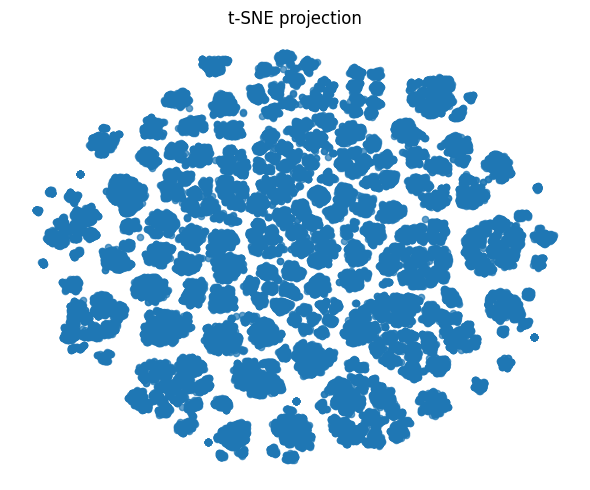

array([[ 35.958977,  11.17174 ],
       [ -9.056833,  65.14747 ],
       [  5.227085,  33.123478],
       ...,
       [-76.5386  ,  16.849934],
       [-63.880688,  12.641262],
       [-64.569786,   9.949482]], dtype=float32)

In [ ]:
#tsne_plot(df)

## AgglomerativeClustering

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import gower                     
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

def agglomerative_quality_plot(
    X,
    n_clusters_range=range(2, 11),
    linkage="average",            
    metric="euclidean",          
    compute_metrics=("silhouette", "davies_bouldin", "calinski_harabasz"),
):
    

    use_gower = (metric == "gower")
    if use_gower and linkage == "ward":
        raise ValueError("Cannot use 'ward' linkage with Gower metric.")
    if use_gower:
        D = gower.gower_matrix(X)

    
    results = {m: [] for m in compute_metrics}
    header = f"{'k':^3s} | {'#clusters':^8s}" + "".join(
        f" | {m.replace('_',' ').title():^18s}" for m in compute_metrics
    )
    print(header)
    print("-" * len(header))

    for k in n_clusters_range:
    
        kwargs = {"n_clusters": k, "linkage": linkage}
        if use_gower:
            kwargs["metric"] = "precomputed"
        elif linkage != "ward":
            kwargs["metric"] = metric

        model = AgglomerativeClustering(**kwargs)
        labels = model.fit_predict(D if use_gower else X)

        n_lab = len(np.unique(labels))
        for m in compute_metrics:
            if n_lab <= 1:
                val = 0.0
            elif m == "silhouette":
                if use_gower:
                    val = silhouette_score(D, labels, metric="precomputed")
                else:
                    val = silhouette_score(X, labels, metric=metric)
            elif m == "davies_bouldin":
                val = davies_bouldin_score(X, labels)
            elif m == "calinski_harabasz":
                val = calinski_harabasz_score(X, labels)
            else:
                raise ValueError(f"Unknown metric: {m}")
            results[m].append(val)

        row = f"{k:^3d} | {n_lab:^8d}" + "".join(
            f" | {results[m][-1]:18.4f}" for m in compute_metrics
        )
        print(row)


    colors = {
        "silhouette": "tab:blue",
        "davies_bouldin": "tab:red",
        "calinski_harabasz": "tab:green"
    }
    n_rows = len(compute_metrics)
    fig, axes = plt.subplots(n_rows, 1, figsize=(8, 3 * n_rows), sharex=True)
    if n_rows == 1:
        axes = [axes]

    for ax, m in zip(axes, compute_metrics):
        ax.plot(
            list(n_clusters_range),
            results[m],
            marker="o",
            color=colors[m],
            label=m.replace("_", " ").title()
        )
        ax.set_ylabel(m.replace("_", " ").title())
        ax.grid(alpha=0.4)
        ax.legend()

    axes[-1].set_xlabel("Number of clusters (k)")
    plt.suptitle(f"Agglomerative (linkage={linkage}, metric={metric})", y=0.93)
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()


 k  | clusters |     Silhouette     |   Davies Bouldin   | Calinski Harabasz 
------------------------------------------------------------------------------
 2  |        2 |             0.1914 |             2.0451 |          4715.0978


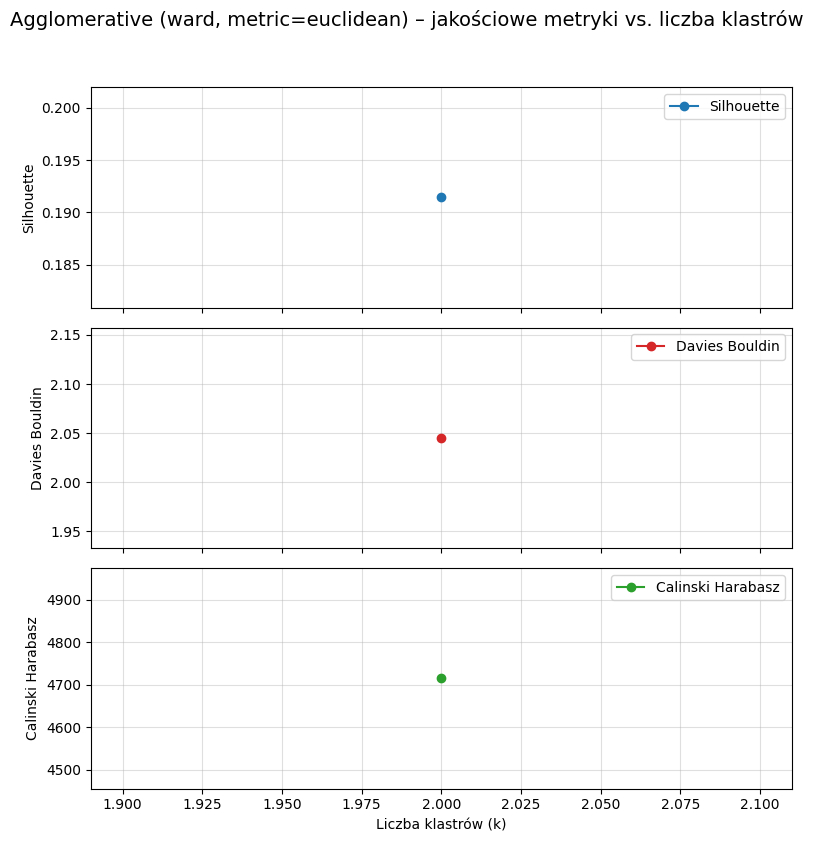

In [ ]:
agglomerative_quality_plot(df,n_clusters_range=range(2,3),metric='euclidian')

 k  | #clusters |     Silhouette     |   Davies Bouldin   | Calinski Harabasz 
------------------------------------------------------------------------------
 2  |    2     |             0.2494 |             1.6312 |             5.9214


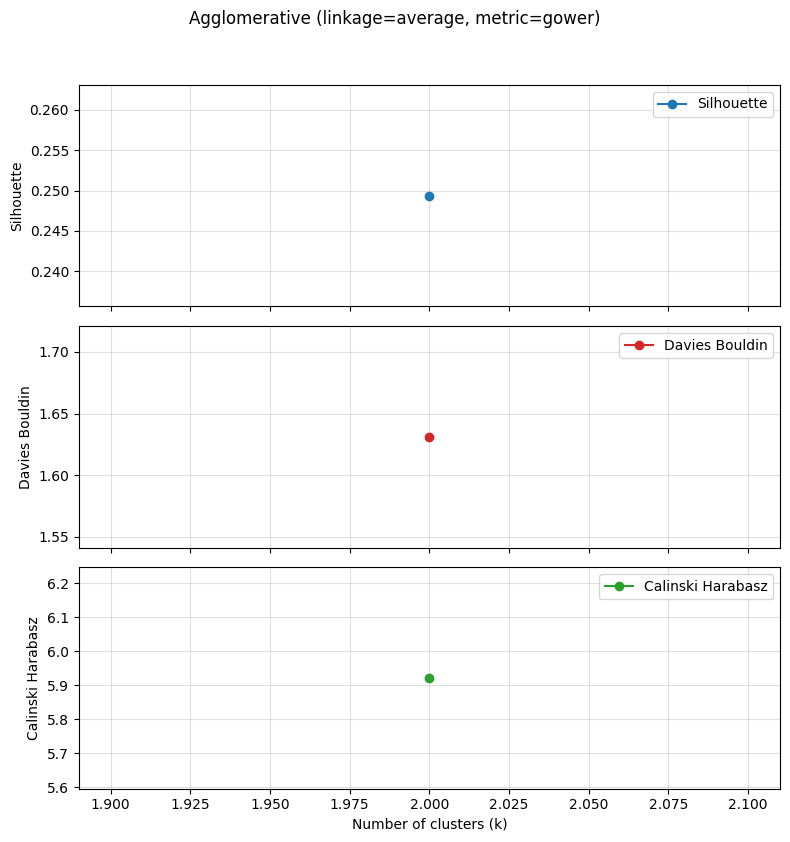

In [23]:
agglomerative_quality_plot(df,n_clusters_range=range(2,3),metric='gower')

## Kmeans

In [15]:
def KMeans_plotter(X, lower_bound=2, upper_bound=20):
    if lower_bound < 2:
        raise ValueError("lower_bound must be at least 2.")
    
    inertia_list = []
    silhouette_list = []
    

    for i in range(lower_bound, upper_bound + 1):
        k = KMeans(n_clusters=i, random_state=42)
        k.fit(X)
        predicted = k.predict(X)
        inertia_list.append(k.inertia_)
        silhouette_list.append(silhouette_score(X, predicted))
    
    x_cord = np.arange(lower_bound, upper_bound + 1)
    
    
    
    fig, ax1 = plt.subplots(figsize=(8, 5))



    ax1.plot(x_cord, inertia_list, color='blue', linewidth=2, label='Inertia ')

    ax1.set_xlabel('Number of clusters (k)')
    ax1.set_ylabel('Inertia', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True, linestyle='--', alpha=0.5)


    ax2 = ax1.twinx()

    ax2.plot(x_cord, silhouette_list, color='orange', linewidth=2, label='Silhouette ')

    ax2.set_ylabel('Silhouette Score', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')


    legend1 = ax1.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0))
    for text in legend1.get_texts():
        text.set_color('blue')

    legend2 = ax2.legend(loc='upper right', bbox_to_anchor=(1.0, 0.92))
    for text in legend2.get_texts():
        text.set_color('orange')

    plt.title('Inertia and Silhouette Scores vs. Number of Clusters')
    plt.tight_layout()


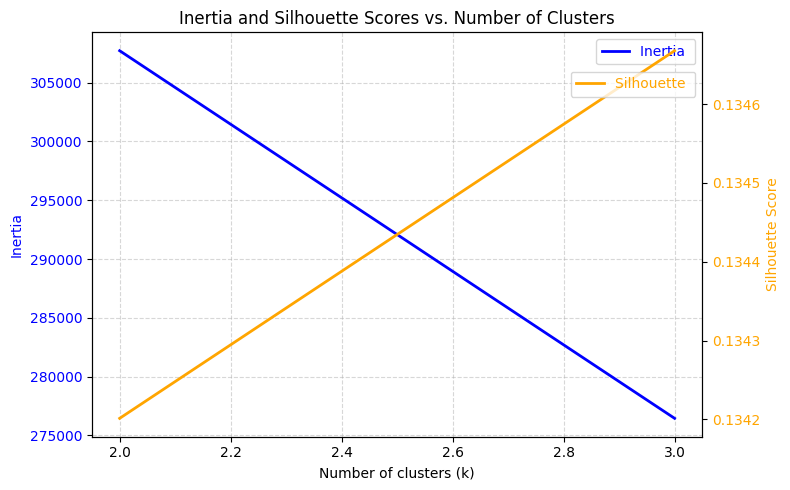

In [ ]:
KMeans_plotter(df,2,3)

## Kmedoids

In [16]:

def KMedoids_plotter(
    X,
    lower_bound=2,
    upper_bound=20,
    metric='euclidean',
    random_state=42
):

    if lower_bound < 2:
        raise ValueError("lower_bound must be at least 2.")
    if upper_bound < lower_bound:
        raise ValueError("upper_bound must be >= lower_bound.")

    
    use_precomputed = (metric == 'gower')
    if use_precomputed:
        D = gower.gower_matrix(X)  
        fit_data = D
        km_kwargs = {'metric': 'precomputed'}
    else:
        fit_data = X
        km_kwargs = {'metric': metric}

    inertia_list = []
    silhouette_list = []
    ks = np.arange(lower_bound, upper_bound + 1)

    for k in ks:
        km = KMedoids(
            n_clusters=k,
            random_state=random_state,
            method='pam',
            **km_kwargs
        )
        labels = km.fit_predict(fit_data)

       
        inertia_list.append(km.inertia_)

        
        if len(np.unique(labels)) > 1:
            sil = silhouette_score(
                fit_data,
                labels,
                metric='precomputed' if use_precomputed else metric
            )
        else:
            sil = 0.0
        silhouette_list.append(sil)
        
    fig, ax1 = plt.subplots(figsize=(8, 5))

    ax1.plot(
        ks,
        inertia_list,
        color='blue',
        linewidth=2,
        marker='o',
        label='Inertia'
    )
    ax1.set_xlabel('Number of clusters (k)')
    ax1.set_ylabel('Inertia', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True, linestyle='--', alpha=0.5)

    ax2 = ax1.twinx()
    ax2.plot(
        ks,
        silhouette_list,
        color='orange',
        linewidth=2,
        marker='s',
        label='Silhouette'
    )
    ax2.set_ylabel('Silhouette Score', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')

    l1 = ax1.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0))
    for text in l1.get_texts():
        text.set_color('blue')
    l2 = ax2.legend(loc='upper right', bbox_to_anchor=(1.0, 0.92))
    for text in l2.get_texts():
        text.set_color('orange')

    plt.title('Inertia and Silhouette Scores vs. Number of Clusters (KMedoids)')
    plt.tight_layout()
    plt.show()


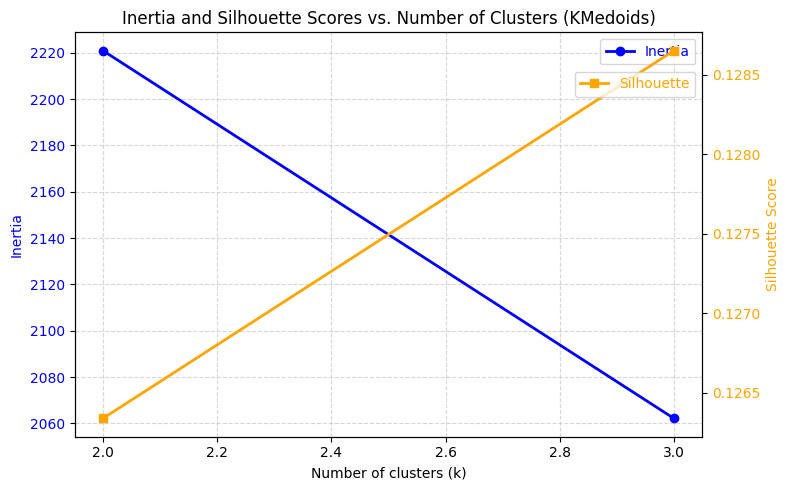

In [17]:
KMedoids_plotter(df,2,3,'gower')

In [ ]:
KMedoids_plotter(df,2,3,'euclidian') 

## DB SCAN 

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import gower                    # pip install gower
from sklearn.cluster import DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

def DBScanner(X, params_list, use_gower=False):
    if not params_list:
        raise ValueError("params_list cannot be empty")

    
    if use_gower:
        D = gower.gower_matrix(X)  

    silhouette_list = []
    db_index_list  = []
    ch_score_list  = []

    for i, param in enumerate(params_list):
        
        db_args = param.copy()
        if use_gower:
            db_args['metric'] = 'precomputed'
            db = DBSCAN(**db_args)
            labels = db.fit_predict(D)
        else:
            db = DBSCAN(**db_args)
            labels = db.fit_predict(X)

        unique = set(labels) - {-1}
        if len(unique) <= 1:
            print(f"param_nr_{i}: Outliers or ≤1 cluster → metrics = 0")
            silhouette_list.append(0.0)
            db_index_list.append(0.0)
            ch_score_list.append(0.0)
            continue

        
        if use_gower:
            sil = silhouette_score(D, labels, metric='precomputed')
        else:
            sil = silhouette_score(X, labels)
        silhouette_list.append(sil)

        
        if not use_gower:
            dbi = davies_bouldin_score(X, labels)
            chs = calinski_harabasz_score(X, labels)
        else:
            dbi = 0.0
            chs = 0.0

        db_index_list.append(dbi)
        ch_score_list.append(chs)

        print(f"param_nr_{i}: Silhouette={sil:.4f}, DBI={dbi:.4f}, CH={chs:.4f}")

    
    labels = [f"param_{i}" for i in range(len(params_list))]
    x = np.arange(len(params_list))

    fig, axs = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

    axs[0].plot(x, silhouette_list, marker='o', color='tab:blue')
    axs[0].set_ylabel('Silhouette', color='tab:blue')
    axs[0].grid(alpha=0.3)

    axs[1].plot(x, db_index_list, marker='s', color='tab:red')
    axs[1].set_ylabel('Davies–Bouldin', color='tab:red')
    axs[1].grid(alpha=0.3)

    axs[2].plot(x, ch_score_list, marker='^', color='tab:green')
    axs[2].set_ylabel('Calinski–Harabasz', color='tab:green')
    axs[2].set_xlabel('Param set index')
    axs[2].grid(alpha=0.3)

    plt.xticks(x, labels, rotation=45)
    plt.suptitle(
        'DBSCAN metrics vs. parameter set' + 
        (' (Gower precomputed)' if use_gower else '')
    )
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()


In [33]:
params_list = [
    {"eps": 1, "min_samples": 5},
    {"eps": 2, "min_samples": 10},
    {"eps": 3, "min_samples": 5}, 
    {"eps":4,"min_samples": 10},
    {"eps":5,"min_samples":15}
]

param_nr_0: Silhouette = -0.4074, Davies–Bouldin = 1.8333, Calinski–Harabasz = 12.4691
param_nr_1: Outliers or only one cluster → metryki = 0


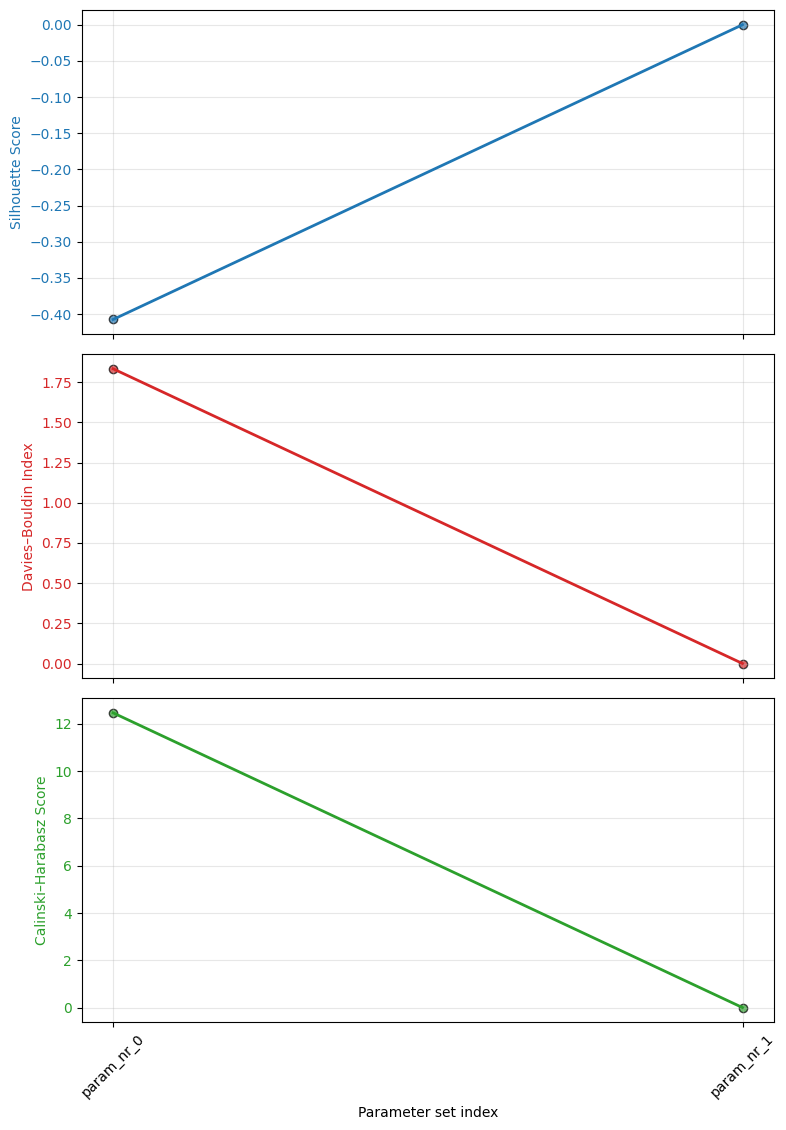

In [ ]:
DBScanner(df, params_list)

In [ ]:
DBScanner(df,param_list,True)

## Gaussian Mixture Models 

In [53]:

def gmm_optimal_components(
    X,
    min_components=1,
    max_components=10,
    criterion='bic',
    random_state=42
):
   
    n_components_range = np.arange(min_components, max_components + 1)
    aic_values = []
    bic_values = []




    for n in n_components_range:
        
        gmm = GaussianMixture(n_components=n, random_state=random_state)
        gmm.fit(X)

     
        aic = gmm.aic(X)
        bic = gmm.bic(X)
        aic_values.append(aic)
        bic_values.append(bic)


    
    plt.figure(figsize=(8, 5))

    plt.plot(n_components_range, aic_values, marker='o', color='steelblue', label='AIC')
    plt.plot(n_components_range, bic_values, marker='s', color='salmon', label='BIC')


    plt.xticks(n_components_range)
    plt.xlabel('Liczba komponentów (n_components)')
    title = "Kryteria AIC i BIC vs. liczba komponentów (GMM)"
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

   
    if criterion.lower() == 'aic':
        best_idx = np.argmin(aic_values)
        best_n = n_components_range[best_idx]
    elif criterion.lower() == 'bic':
        best_idx = np.argmin(bic_values)
        best_n = n_components_range[best_idx]
    else:
        raise ValueError("Kryterium musi być 'aic' lub 'bic'")

    print(f"\nOptimal {criterion.upper()}: {best_n}")
    return best_n

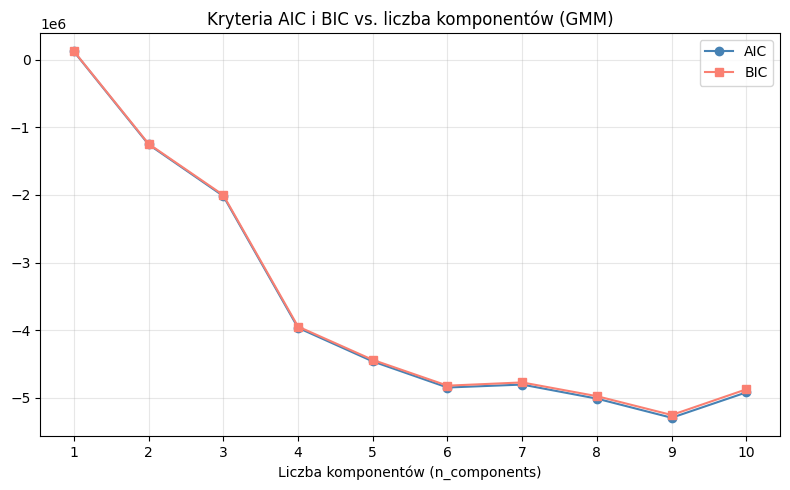


Optimal BIC: 9


9

In [54]:
gmm_optimal_components(df,min_components=1,max_components=10)

## Mean shift 

In [73]:
def meanshift_quality_plot(
    X,
    bandwidth_list,
    metrics=("silhouette", "davies_bouldin", "calinski_harabasz"),
    cluster_all=True,
    n_jobs=None,
):
    
    results = {m: [] for m in metrics}
    n_clusters_list = []

    for bw in bandwidth_list:
        ms = MeanShift(bandwidth=bw, cluster_all=cluster_all, n_jobs=n_jobs)
        labels = ms.fit_predict(X)
        n_clusters = len(np.unique(labels))
        n_clusters_list.append(n_clusters)

        if n_clusters <= 1:
            for m in metrics:
                results[m].append(0.0)
            continue

        if "silhouette" in metrics:
            results["silhouette"].append(silhouette_score(X, labels))
        if "davies_bouldin" in metrics:
            results["davies_bouldin"].append(davies_bouldin_score(X, labels))
        if "calinski_harabasz" in metrics:
            results["calinski_harabasz"].append(
                calinski_harabasz_score(X, labels))

  
    n_metrics = len(metrics)
    fig, axs = plt.subplots(
        n_metrics, 1, figsize=(8, 3 * n_metrics), sharex=True
    )

    if n_metrics == 1:
        axs = [axs]  

    colors = {
        "silhouette": "tab:blue",
        "davies_bouldin": "tab:red",
        "calinski_harabasz": "tab:green",
    }
    for ax, m in zip(axs, metrics):
        ax.plot(
            bandwidth_list,
            results[m],
            marker="o",
            color=colors.get(m, "black"),
            label=m.replace("_", " ").title(),
        )
        ax.set_ylabel(m.replace("_", " ").title())
        ax.grid(alpha=0.4)
        ax.legend()

    axs[-1].set_xlabel("Bandwidth")
    plt.suptitle("Miary jakości klasteryzacji vs. bandwidth", y=0.94)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

    header = "bandwidth | n_clusters " + " ".join(f"| {m:^18s}" for m in metrics)
    print(header)
    print("-" * len(header))
    for i, bw in enumerate(bandwidth_list):
        row = f"{bw:9.3f} | {n_clusters_list[i]:10d} "
        for m in metrics:
            row += f"| {results[m][i]:18.4f} "
        print(row)


In [ ]:
bw_est = estimate_bandwidth(df, quantile=0.2, n_samples=300)
bw_values = np.linspace(bw_est * 0.5, bw_est * 1.5, 8)

meanshift_quality_plot(
        df,
        bandwidth_list=bw_values,
        metrics=("silhouette", "davies_bouldin", "calinski_harabasz"),
    )

KeyboardInterrupt: 